<a href="https://colab.research.google.com/github/b181005/Cellpose-Image-Analysis/blob/main/260323_cellposeAll.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# set up


In [ ]:
dir_path = "/content/drive/MyDrive/DATA/images/Psychatg02_07112025"


In [4]:
%pip install cellpose matplotlib numpy imagecodecs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.3/213.3 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 87.4 MB/s eta 0:00:00


In [5]:
 #single image plot test
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import regionprops
from cellpose import models, plot, io, core
import pandas as pd
import seaborn as sns
import os
import imagecodecs
from pathlib import Path
from natsort import natsorted

io.logger_setup() # run this to get printing of progress

#Check if colab notebook instance has GPU access
if core.use_gpu()==False:
  raise ImportError("No GPU access, change your runtime to one with GPU")

creating new log file
2026-03-26 22:49:02,366 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-03-26 22:49:02,367 [INFO] 
cellpose version: 	4.1.0 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128
2026-03-26 22:49:02,779 [INFO] ** TORCH CUDA version installed and working. **


# Google Drive

In [6]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
!ls /content/drive/MyDrive/DATA/

Mounted at /content/drive
images


In [17]:
# 1. Define path with a default fallback
try:
    dir_path = dir_path
except NameError:
    dir_path = "/content/drive/MyDrive/DATA/images/Psychatg02_07112025"

dir_obj = Path(dir_path)

if not dir_obj.exists():
    raise FileNotFoundError(f"Directory not found: {dir_path}")

# 2. List the files
image_ext = ".tif"
all_files = list(dir_obj.rglob("*" + image_ext))
files = natsorted([f for f in all_files if "_masks" not in f.name and "_flows" not in f.name])

# 3. Check if files were found
if len(files) == 0:
    print(f"Warning: No {image_ext} files found in {dir_path}")
else:
    print(f"{len(files)} images found.")
    print(f"Success! Found {len(files)} total images across all subfolders.")
    # Show the first 3 paths to verify they are correct
    for f in files[:3]:
        print(f"Found: {f}")

90 images found.
Success! Found 90 total images across all subfolders.
Found: /content/drive/MyDrive/DATA/images/Psychatg02_07112025/Psychatg02_07112025/B+_w1/W001/P00001/HM_W001_P00001_CH2.tif
Found: /content/drive/MyDrive/DATA/images/Psychatg02_07112025/Psychatg02_07112025/B+_w1/W001/P00001/HM_W001_P00001_CH4.tif
Found: /content/drive/MyDrive/DATA/images/Psychatg02_07112025/Psychatg02_07112025/B+_w1/W001/P00001/HM_W001_P00001_Overlay.tif


In [8]:
# 1. Define your base path and conditions
study_map = {
    "Control": "B+_w1",
    "Condition": "S+B+_w1"
}

# 2. Initialize a dictionary to hold the separated file paths
separated_files = {key: [] for key in study_map.keys()}

# 3. Loop through the folders and sort files
# We use rglob to find all .tif files recursively
for file_path in dir_obj.rglob("*.tif"):
    # Skip masks or flows if they exist to avoid duplicates
    if "_masks" in file_path.name or "_flows" in file_path.name:
        continue

    # Check which condition folder the file belongs to
    for label, folder_keyword in study_map.items():
        if folder_keyword in str(file_path):
            separated_files[label].append(file_path)

# 4. Verify the results
for label, files in separated_files.items():
    print(f"{label}: found {len(files)} images.")
    if files:
        print(f"   Example: {files[0].name}")

Control: found 36 images.
   Example: HM_W001_P00002_CH2.tif
Condition: found 18 images.
   Example: HM_W001_P00001_Overlay.tif


In [15]:
def run_cell_analysis(ch2_path, condition_label):
    """
    Performs feature extraction using existing masks if available,
    otherwise runs Cellpose segmentation.
    """
    print(f"--- Analyzing: {os.path.basename(ch2_path)} ---")
    global rows
    global primary_id

    p = Path(ch2_path)
    ch4_path = p.with_name(p.name.replace("_CH2.tif", "_CH4.tif"))
    mask_path = p.with_name(p.stem + "_masks.tif")

    if not ch4_path.exists():
        print(f"Skipping: CH4 pair not found for {p.name}")
        return

    # Load Images
    ch2_img = io.imread(str(p))
    ch4_img = io.imread(str(ch4_path))

    # Check for existing masks
    if mask_path.exists():
        print(f"Using existing mask: {mask_path.name}")
        masks = io.imread(str(mask_path))
    else:
        print("No mask found. Running Cellpose segmentation...")
        # Run Cellpose
        masks_output, flows, styles = model.eval([ch2_img], diameter=30, channels=[0,0])
        masks = masks_output[0]

    # Measure Properties
    props = regionprops(masks, intensity_image=ch2_img)
    ch4_props = regionprops(masks, intensity_image=ch4_img)

    file_name = p.stem

    for p_gfp, p_s647 in zip(props, ch4_props):
        rows.append({
            "file": file_name,
            "condition": condition_label,
            "cell_id": p_gfp.label,
            "area_px": p_gfp.area,
            "mean_gfp": p_gfp.mean_intensity,
            "mean_s647": p_s647.mean_intensity
        })
    primary_id += 1

In [11]:
# --- Execute the function for both channels ---
# 1. Run analysis for CH2
# CH_basepath = "C:/Users/labadmin/Documents/BZ-X800/Chris/Psychatg02_07112025/"
# ch2_path = os.path.join(CH_basepath, filename + "_CH2.tif")
# CH2 = img
# CH4 = "/content/drive/MyDrive/cellpose_data/Psychatg02_07112025/S+B+_w1/W001/P00001/HM_W001_P00001_CH4.tif"

# run_cell_analysis(CH2)
# df_Splus = pd.DataFrame(rows)

# CH2 = img2
# CH4 = "/content/drive/MyDrive/cellpose_data/Psychatg02_07112025/B+_w1/W001/P00001/HM_W001_P00001_CH4.tif"
# run_cell_analysis(CH2)
# df_Sminus = pd.DataFrame(rows)
# df_all = pd.DataFrame(rows)

# print(f"df_Splus now has {len(df_Splus)} rows.")
# print(f"df_Sminus now has {len(df_Sminus)} rows.")

In [31]:
from cellpose import models, io, core
import pandas as pd
import numpy as np
import os
from pathlib import Path

# 1. Initialize the Cellpose model
model = models.CellposeModel(gpu=True)

# 2. Initialize data storage
rows = []
primary_id = 1

# 3. Define the cleanup helper inside the loop cell to ensure it is used
def get_scalar(val):
    # If it is an array/list (like [R, G, B]), take the max or a specific channel
    if isinstance(val, (list, np.ndarray)) and len(np.atleast_1d(val)) > 1:
        return np.max(val)
    return val

# 4. Loop through every condition
for condition, file_list in separated_files.items():
    print(f"\nProcessing group: {condition}")
    ch2_files = [f for f in file_list if "_CH2.tif" in f.name]

    for file_path in ch2_files:
        run_cell_analysis(str(file_path), condition)

# 5. Create and clean the DataFrame
df_combined = pd.DataFrame(rows)

if not df_combined.empty:
    # Apply scalar conversion to the intensity columns
    df_combined['mean_gfp'] = df_combined['mean_gfp'].apply(get_scalar)
    df_combined['mean_s647'] = df_combined['mean_s647'].apply(get_scalar)

    # Recalculate ratio
    df_combined['ratio_647_gfp'] = df_combined['mean_s647'] / (df_combined['mean_gfp'] + 1e-9)

    print(f"\nDone! Total cells analyzed: {len(df_combined)}")
    display(df_combined.head())
else:
    print("No data collected.")

2026-03-26 23:13:33,280 [INFO] ** TORCH CUDA version installed and working. **
2026-03-26 23:13:33,281 [INFO] >>>> using GPU (CUDA)
2026-03-26 23:13:35,893 [INFO] >>>> loading model /root/.cellpose/models/cpsam

Processing group: Control
--- Analyzing: HM_W001_P00002_CH2.tif ---
Using existing mask: HM_W001_P00002_CH2_masks.tif
--- Analyzing: HM_W001_P00004_CH2.tif ---
Using existing mask: HM_W001_P00004_CH2_masks.tif
--- Analyzing: HM_W001_P00005_CH2.tif ---
Using existing mask: HM_W001_P00005_CH2_masks.tif
--- Analyzing: HM_W001_P00003_CH2.tif ---
Using existing mask: HM_W001_P00003_CH2_masks.tif
--- Analyzing: HM_W001_P00001_CH2.tif ---
Using existing mask: HM_W001_P00001_CH2_masks.tif
--- Analyzing: HM_W001_P00006_CH2.tif ---
Using existing mask: HM_W001_P00006_CH2_masks.tif
--- Analyzing: HM_W001_P00001_CH2.tif ---
Using existing mask: HM_W001_P00001_CH2_masks.tif
--- Analyzing: HM_W001_P00004_CH2.tif ---
Using existing mask: HM_W001_P00004_CH2_masks.tif
--- Analyzing: HM_W001_P00

,file,condition,cell_id,area_px,mean_gfp,mean_s647,ratio_647_gfp
0,HM_W001_P00002_CH2,Control,1,98.0,34.163265,12.469388,0.364994
1,HM_W001_P00002_CH2,Control,2,178.0,19.084270,12.584270,0.659405
2,HM_W001_P00002_CH2,Control,3,17.0,35.235294,24.941176,0.707846
3,HM_W001_P00002_CH2,Control,4,46.0,81.695652,14.260870,0.174561
4,HM_W001_P00002_CH2,Control,5,134.0,27.701493,15.753731,0.568696


In [13]:
df = pd.DataFrame(rows)
df

,file,condition,cell_id,area_px,mean_gfp,mean_s647
0,HM_W001_P00002_CH2,Control,1,98.0,"[0.0, 34.16326530612245, 0.0]","[12.46938775510204, 0.0, 12.46938775510204]"
1,HM_W001_P00002_CH2,Control,2,178.0,"[0.0, 19.084269662921347, 0.0]","[12.584269662921349, 0.0, 12.584269662921349]"
2,HM_W001_P00002_CH2,Control,3,17.0,"[0.0, 35.23529411764706, 0.0]","[24.941176470588236, 0.0, 24.941176470588236]"
3,HM_W001_P00002_CH2,Control,4,46.0,"[0.0, 81.69565217391305, 0.0]","[14.26086956521739, 0.0, 14.26086956521739]"
4,HM_W001_P00002_CH2,Control,5,134.0,"[0.0, 27.70149253731343, 0.0]","[15.753731343283581, 0.0, 15.753731343283581]"
...,...,...,...,...,...,...
3003,HM_W001_P00005_CH2,Condition,123,133.0,"[0.0, 30.022556390977442, 0.0]","[21.037593984962406, 0.0, 21.037593984962406]"
3004,HM_W001_P00005_CH2,Condition,124,101.0,"[0.0, 16.217821782178216, 0.0]","[12.257425742574258, 0.0, 12.257425742574258]"
3005,HM_W001_P00005_CH2,Condition,125,129.0,"[0.0, 26.511627906976745, 0.0]","[13.294573643410853, 0.0, 13.294573643410853]"
3006,HM_W001_P00005_CH2,Condition,126,178.0,"[0.0, 30.331460674157302, 0.0]","[20.702247191011235, 0.0, 20.702247191011235]"


In [19]:
# Separate the combined data into two DataFrames
df_control = df_combined[df_combined['condition'] == 'Control'].copy()
df_experimental = df_combined[df_combined['condition'] == 'Condition'].copy()

print(f"Control cells: {len(df_control)}")
print(f"Experimental cells: {len(df_experimental)}")

print("\n--- Control Preview ---")
display(df_control.head())

print("\n--- Experimental Preview ---")
display(df_experimental.head())


Control cells: 2086
Experimental cells: 922

--- Control Preview ---


,file,condition,cell_id,area_px,mean_gfp,mean_s647,ratio_647_gfp
0,HM_W001_P00002_CH2,Control,1,98.0,34.163265,0.0,0.0
1,HM_W001_P00002_CH2,Control,2,178.0,19.084270,0.0,0.0
2,HM_W001_P00002_CH2,Control,3,17.0,35.235294,0.0,0.0
3,HM_W001_P00002_CH2,Control,4,46.0,81.695652,0.0,0.0
4,HM_W001_P00002_CH2,Control,5,134.0,27.701493,0.0,0.0



--- Experimental Preview ---


,file,condition,cell_id,area_px,mean_gfp,mean_s647,ratio_647_gfp
2086,HM_W001_P00001_CH2,Condition,1,188.0,33.446809,0.0,0.0
2087,HM_W001_P00001_CH2,Condition,2,73.0,23.986301,0.0,0.0
2088,HM_W001_P00001_CH2,Condition,3,305.0,25.859016,0.0,0.0
2089,HM_W001_P00001_CH2,Condition,4,84.0,29.130952,0.0,0.0
2090,HM_W001_P00001_CH2,Condition,5,171.0,40.871345,0.0,0.0


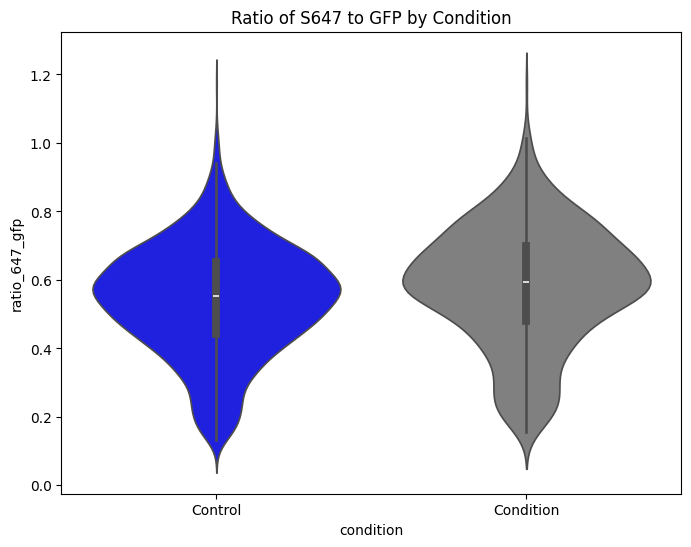

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.violinplot(
    data=df_combined,
    x='condition',
    y='ratio_647_gfp',
    hue='condition',
    legend=False,
    palette=['blue', 'gray'],
    order=['Control', 'Condition']
)
plt.title('Ratio of S647 to GFP by Condition')
plt.show()

In [25]:
import tifffile

def save_all_masks(separated_files, model):
    for condition, file_list in separated_files.items():
        ch2_files = [f for f in file_list if '_CH2.tif' in f.name]
        for p in ch2_files:
            mask_path = p.with_name(p.stem + '_masks.tif')
            if not mask_path.exists():
                print(f'Generating and saving mask for: {p.name}')
                img = io.imread(str(p))
                masks_output, flows, styles = model.eval([img], diameter=30, channels=[0,0])
                masks = masks_output[0]
                tifffile.imwrite(str(mask_path), masks.astype(np.uint16))
            else:
                print(f'Mask already exists for: {p.name}')

save_all_masks(separated_files, model)

Generating and saving mask for: HM_W001_P00002_CH2.tif
2026-03-26 23:07:16,920 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
Generating and saving mask for: HM_W001_P00004_CH2.tif
2026-03-26 23:07:21,503 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
Generating and saving mask for: HM_W001_P00005_CH2.tif
2026-03-26 23:07:26,048 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
Generating and saving mask for: HM_W001_P00003_CH2.tif
2026-03-26 23:07:30,649 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
Generating and saving mask for: HM_W001_P00001_CH2.tif
2026-03-26 23:07:35,346 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
Generating

In [26]:
import tifffile
from cellpose import io
import numpy as np

def save_missing_masks(separated_files, model):
    for condition, file_list in separated_files.items():
        ch2_files = [f for f in file_list if '_CH2.tif' in f.name]
        for p in ch2_files:
            mask_path = p.with_name(p.stem + '_masks.tif')
            if not mask_path.exists():
                print(f'Generating and saving mask: {mask_path.name}')
                img = io.imread(str(p))
                masks_output, flows, styles = model.eval([img], diameter=30, channels=[0,0])
                masks = masks_output[0]
                tifffile.imwrite(str(mask_path), masks.astype(np.uint16))
            else:
                print(f'Mask already exists: {mask_path.name}')

save_missing_masks(separated_files, model)

Mask already exists: HM_W001_P00002_CH2_masks.tif
Mask already exists: HM_W001_P00004_CH2_masks.tif
Mask already exists: HM_W001_P00005_CH2_masks.tif
Mask already exists: HM_W001_P00003_CH2_masks.tif
Mask already exists: HM_W001_P00001_CH2_masks.tif
Mask already exists: HM_W001_P00006_CH2_masks.tif
Mask already exists: HM_W001_P00001_CH2_masks.tif
Mask already exists: HM_W001_P00004_CH2_masks.tif
Mask already exists: HM_W001_P00002_CH2_masks.tif
Mask already exists: HM_W001_P00003_CH2_masks.tif
Mask already exists: HM_W001_P00006_CH2_masks.tif
Mask already exists: HM_W001_P00005_CH2_masks.tif
Mask already exists: HM_W001_P00001_CH2_masks.tif
Mask already exists: HM_W001_P00004_CH2_masks.tif
Mask already exists: HM_W001_P00002_CH2_masks.tif
Mask already exists: HM_W001_P00003_CH2_masks.tif
Mask already exists: HM_W001_P00006_CH2_masks.tif
Mask already exists: HM_W001_P00005_CH2_masks.tif


In [ ]:
df_combined

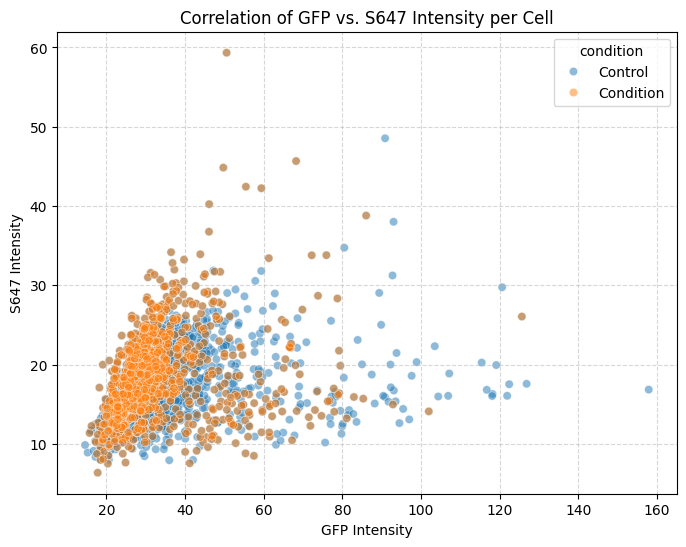

In [33]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_combined,
    x='mean_gfp',
    y='mean_s647',
    hue='condition',
    alpha=0.5
)

plt.xlabel("GFP Intensity")
plt.ylabel("S647 Intensity")
plt.title("Correlation of GFP vs. S647 Intensity per Cell")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

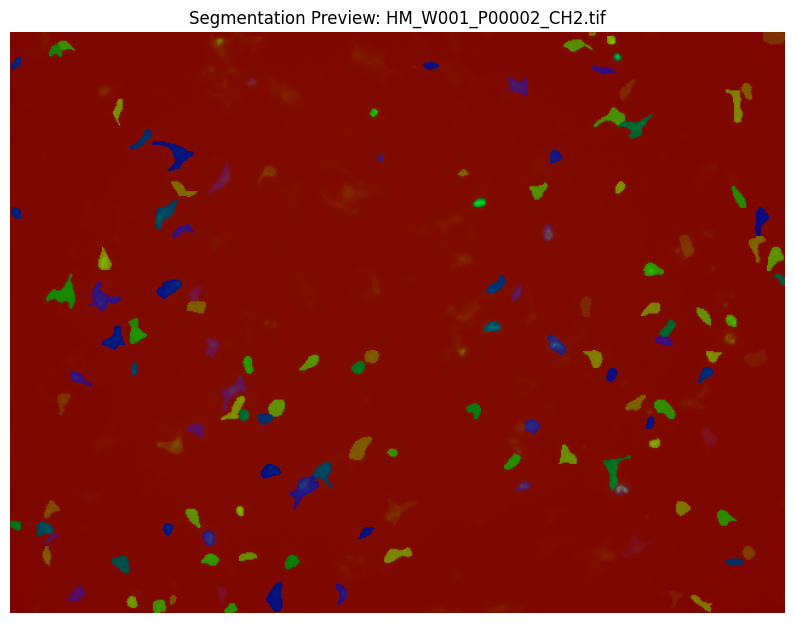

In [27]:
# Segmentation Preview
from cellpose import io, plot
import matplotlib.pyplot as plt
from pathlib import Path

# Grab a CH2 image from the Control group for the preview
if 'separated_files' in locals() and separated_files['Control']:
    ch2_files = [f for f in separated_files['Control'] if '_CH2.tif' in f.name]
    if ch2_files:
        test_file = ch2_files[0]
        img = io.imread(str(test_file))
        # The mask was saved with the same stem + _masks.tif
        mask_path = test_file.with_name(test_file.stem + '_masks.tif')

        if mask_path.exists():
            masks = io.imread(str(mask_path))
            plt.figure(figsize=(10, 8))
            plt.imshow(img, cmap='gray')
            plt.imshow(masks, alpha=0.5, cmap='prism')
            plt.title(f'Segmentation Preview: {test_file.name}')
            plt.axis('off')
            plt.show()
        else:
            print(f'Mask file not found at: {mask_path}')
    else:
        print('No CH2 files found in Control group.')
else:
    print('No files found in separated_files.')

File: HM_W001_P00002_CH4.tif
Shape: (480, 640, 3)
Max Intensity: 218
Min Intensity: 0


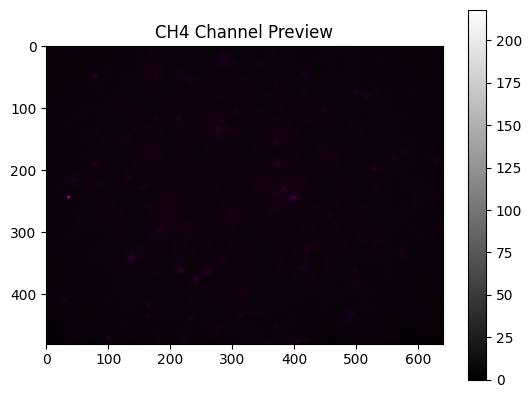

In [30]:
import matplotlib.pyplot as plt

# Let's check the first CH4 file found in the 'Control' group
if 'separated_files' in locals() and separated_files['Control']:
    test_file = separated_files['Control'][0]
    # Construct CH4 path like the analysis function does
    ch4_test_path = test_file.with_name(test_file.name.replace('_CH2.tif', '_CH4.tif'))

    if ch4_test_path.exists():
        ch4_img_test = io.imread(str(ch4_test_path))
        print(f"File: {ch4_test_path.name}")
        print(f"Shape: {ch4_img_test.shape}")
        print(f"Max Intensity: {ch4_img_test.max()}")
        print(f"Min Intensity: {ch4_img_test.min()}")

        plt.imshow(ch4_img_test, cmap='gray')
        plt.title('CH4 Channel Preview')
        plt.colorbar()
        plt.show()
    else:
        print(f"CH4 file not found at: {ch4_test_path}")

In [ ]:
import matplotlib.pyplot as plt

plt.plot([1, 2, 3], [4, 5, 6])
plt.savefig("figure.svg")   # SVG vector
plt.savefig("figure.pdf")   # PDF vector
plt.savefig("figure.eps")   # EPS vector


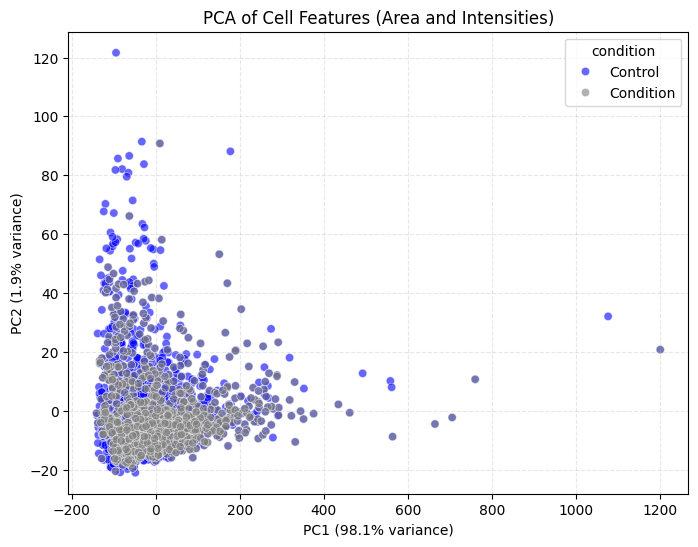

In [24]:
from sklearn.decomposition import PCA
import seaborn as sns

# Prepare numeric data for PCA
numeric_cols = ['area_px', 'mean_gfp', 'mean_s647', 'ratio_647_gfp']
# Ensure we only use rows that have all numeric data
pca_data = df_combined.dropna(subset=numeric_cols)

if not pca_data.empty:
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(pca_data[numeric_cols])

    plt.figure(figsize=(8,6))
    sns.scatterplot(
        x=X_pca[:,0],
        y=X_pca[:,1],
        hue=pca_data['condition'],
        alpha=0.6,
        palette=['blue', 'gray']
    )
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
    plt.title("PCA of Cell Features (Area and Intensities)")
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()
else:
    print('Insufficient data for PCA.')